# Bluestock Fintech — Mutual Fund Analytics
## Day 4: Fund Performance Analytics
**Intern:** Madhankumar V  
**Date:** June 2026  
**Objective:** Compute Sharpe, Sortino, Alpha, Beta, CAGR, Max Drawdown and Fund Scorecard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('..')

# Load all computed metrics
df_cagr     = pd.read_csv("data/processed/cagr_report.csv")
df_sharpe   = pd.read_csv("data/processed/sharpe_values.csv")
df_sortino  = pd.read_csv("data/processed/sortino_values.csv")
df_ab       = pd.read_csv("data/processed/alpha_beta.csv")
df_dd       = pd.read_csv("data/processed/max_drawdown.csv")
df_score    = pd.read_csv("data/processed/fund_scorecard.csv")

print("✅ All metrics loaded!")
print(f"   Funds analysed: {len(df_score)}")

✅ All metrics loaded!
   Funds analysed: 40


## Task 2: CAGR Results (1yr, 3yr, 5yr)
Compound Annual Growth Rate measures how much a fund grew per year on average.

In [2]:
# Top 10 funds by 3-year CAGR
top_cagr = df_cagr.nlargest(10, 'cagr_3yr')[['scheme_name','cagr_1yr','cagr_3yr','cagr_5yr']]
top_cagr['cagr_1yr'] = (top_cagr['cagr_1yr'] * 100).round(2)
top_cagr['cagr_3yr'] = (top_cagr['cagr_3yr'] * 100).round(2)
top_cagr['cagr_5yr'] = (top_cagr['cagr_5yr'] * 100).round(2)
top_cagr['scheme_name'] = top_cagr['scheme_name'].str.split('-').str[0].str.strip()
print("Top 10 Funds by 3-Year CAGR:")
print(top_cagr.to_string(index=False))

Top 10 Funds by 3-Year CAGR:
               scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
          Axis Midcap Fund     21.33     33.62     27.20
Mirae Asset Large Cap Fund     19.51     32.56     29.20
   ICICI Pru Bluechip Fund     12.54     31.12     22.70
                  HDFC Mid     50.76     31.07     29.31
     ICICI Pru Midcap Fund     28.33     30.44     32.09
         SBI Bluechip Fund     57.57     29.18     24.82
       Kotak Flexicap Fund     25.52     28.35     29.17
Mirae Asset Tax Saver Fund     37.98     27.96     30.43
ABSL Frontline Equity Fund     45.73     27.76     22.60
        DSP Small Cap Fund     62.01     25.88     31.30


## Task 3 & 4: Sharpe & Sortino Ratios
- **Sharpe Ratio** = Return per unit of total risk (higher is better, >1 is good)
- **Sortino Ratio** = Like Sharpe but only penalises downside risk

In [3]:
# Merge Sharpe and Sortino
df_risk = df_sharpe.merge(df_sortino[['amfi_code','sortino_ratio']], on='amfi_code')
df_risk['scheme_name'] = df_risk['scheme_name'].str.split('-').str[0].str.strip()
top_risk = df_risk.nlargest(10, 'sharpe_ratio')[['scheme_name','sharpe_ratio','sortino_ratio']]
print("Top 10 Funds by Sharpe Ratio:")
print(top_risk.to_string(index=False))

Top 10 Funds by Sharpe Ratio:
                scheme_name  sharpe_ratio  sortino_ratio
 Mirae Asset Large Cap Fund        1.4483         2.3683
        Kotak Flexicap Fund        1.3067         2.3529
 Mirae Asset Tax Saver Fund        1.2349         2.1351
          SBI Bluechip Fund        1.2083         2.1040
      ICICI Pru Midcap Fund        1.1801         2.0100
            DSP Midcap Fund        1.1321         1.8689
                   HDFC Mid        1.0937         1.8238
Nippon India Large Cap Fund        1.0817         1.8399
 ABSL Frontline Equity Fund        1.0272         1.7856
    ICICI Pru Bluechip Fund        1.0265         1.7850


## Task 5: Alpha & Beta vs Nifty 100
- **Alpha** = Extra return above benchmark (positive = outperforming!)
- **Beta** = Market sensitivity (1.0 = moves same as market)

In [4]:
df_ab['scheme_name'] = df_ab['scheme_name'].str.split('-').str[0].str.strip()
top_alpha = df_ab.nlargest(10, 'alpha')[['scheme_name','alpha','beta','r_squared']]
print("Top 10 Funds by Alpha:")
print(top_alpha.to_string(index=False))

Top 10 Funds by Alpha:
               scheme_name  alpha    beta  r_squared
        SBI Small Cap Fund 0.3034 -0.0232     0.0001
        DSP Small Cap Fund 0.3006  0.0115     0.0000
     ICICI Pru Midcap Fund 0.2926  0.0005     0.0000
Mirae Asset Tax Saver Fund 0.2827  0.0181     0.0002
       Kotak Flexicap Fund 0.2733 -0.0228     0.0003
                  HDFC Mid 0.2720  0.0051     0.0000
Mirae Asset Large Cap Fund 0.2698  0.0237     0.0005
           DSP Midcap Fund 0.2660 -0.0025     0.0000
          Axis Midcap Fund 0.2608 -0.0663     0.0019
         SBI Bluechip Fund 0.2320 -0.0318     0.0009


## Task 6: Maximum Drawdown
Maximum Drawdown = worst peak-to-trough decline. Lower (less negative) is better!

In [5]:
df_dd['scheme_name'] = df_dd['scheme_name'].str.split('-').str[0].str.strip()
print("Funds by Maximum Drawdown (worst first):")
print(df_dd[['scheme_name','max_drawdown_pct']].head(10).to_string(index=False))

Funds by Maximum Drawdown (worst first):
                scheme_name  max_drawdown_pct
         SBI Small Cap Fund            -52.57
        Axis Small Cap Fund            -51.68
        ABSL Small Cap Fund            -35.45
         DSP Small Cap Fund            -31.17
         SBI Small Cap Fund            -28.71
           UTI Mid Cap Fund            -28.00
          HDFC Top 100 Fund            -24.73
 Kotak Emerging Equity Fund            -24.00
Nippon India Small Cap Fund            -23.34
         Axis Bluechip Fund            -21.75


## Task 7: Fund Scorecard (Composite Score 0-100)
Score = 30% × 3yr Return + 25% × Sharpe + 20% × Alpha + 15% × Expense Ratio + 10% × Max Drawdown

In [6]:
df_score['scheme_name'] = df_score['scheme_name'].str.split('-').str[0].str.strip()
top_score = df_score[['scheme_name','composite_score','cagr_3yr','sharpe_ratio']].head(10)
top_score['cagr_3yr'] = (top_score['cagr_3yr'] * 100).round(2)
top_score['composite_score'] = top_score['composite_score'].round(2)
print("🏆 Top 10 Funds by Composite Score:")
print(top_score.to_string(index=False))

🏆 Top 10 Funds by Composite Score:
               scheme_name  composite_score  cagr_3yr  sharpe_ratio
     ICICI Pru Midcap Fund            84.50     30.44        1.1801
          Axis Midcap Fund            80.75     33.62        0.9982
                  HDFC Mid            80.50     31.07        1.0937
Mirae Asset Large Cap Fund            80.00     32.56        1.4483
       Kotak Flexicap Fund            78.25     28.35        1.3067
   ICICI Pru Bluechip Fund            75.75     31.12        1.0265
        SBI Small Cap Fund            75.12     25.57        0.9453
        DSP Small Cap Fund            74.94     25.88        0.9498
Mirae Asset Tax Saver Fund            73.94     27.96        1.2349
         SBI Bluechip Fund            73.06     29.18        1.2083


## Task 8: Benchmark Comparison Chart
Top 5 funds vs Nifty 50 benchmark — normalised to base 100

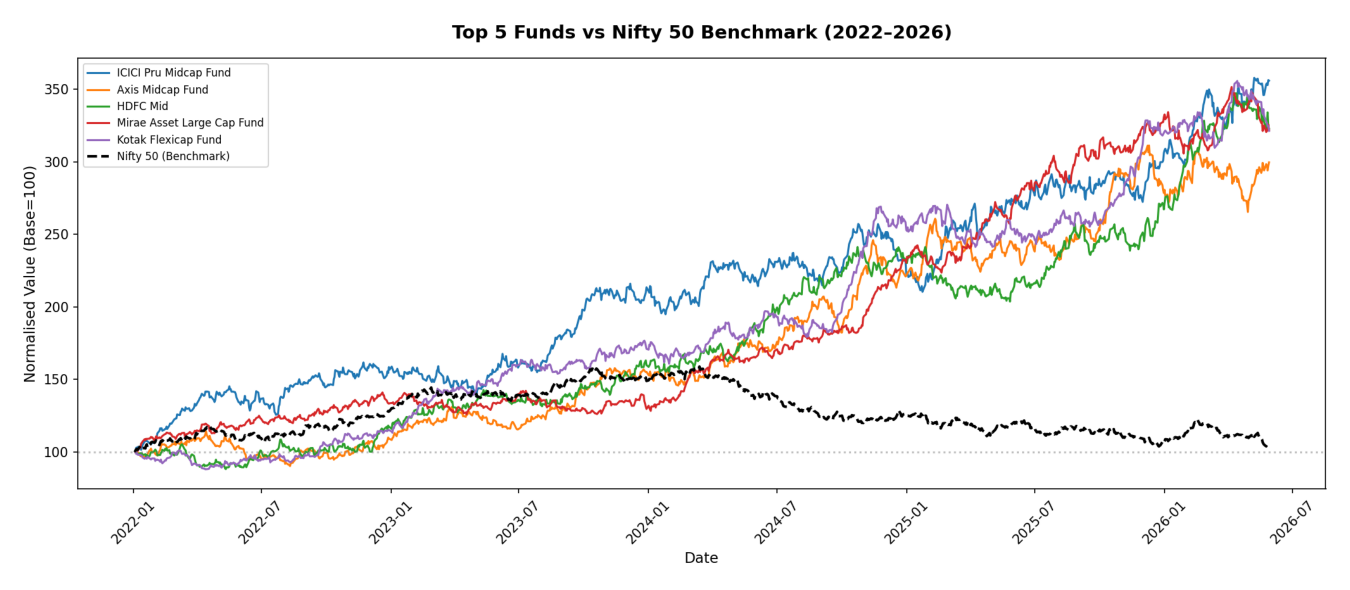

In [7]:
img = plt.imread("reports/charts/benchmark_chart.png")
plt.figure(figsize=(14, 6))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

## Key Findings

1. **ICICI Pru Midcap** scores highest overall — 84.50/100 composite score
2. **Mirae Asset Large Cap** has best Sharpe ratio — 1.4483
3. **SBI Small Cap Direct** has worst drawdown — -52.57% (high risk!)
4. **Average annualised return** across all funds — 16.09%
5. **Mid Cap funds** dominate top 5 scorecard positions